# Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0) # for reproducibility

# Choosing M test values

In [9]:
M_checkpoints = np.unique(np.logspace(3, 8, 26).astype(np.int64)) # 1e3 to 1e8, 0.2 each step
# M has to be a whole number(int) as it is a count => astype
# Sort out the collided/duplicated values => unique

# Sample loop

In [10]:
chunk = 5000000 # divide into smaller batches
inside_tot = 0 # hits inside the circle
n_current = 0 # how many points so far
S_est = np.empty(len(M_checkpoints))  # gonna fill this in as we go

for i, M_target in enumerate(M_checkpoints):  # next checkpoint we're aiming for
    n_needed = M_target - n_current # how much further to go
    while n_needed > 0: # keep chunking
        n = min(chunk, n_needed) # not taking more than one chunk at a time
        x = rng.uniform(-1.0, 1.0, n) #random x's
        y = rng.uniform(-1.0, 1.0, n) #random y's
        inside_tot += np.count_nonzero(x*x + y*y < 1.0) # how many landed in the circle
        n_current += n # tick up the total
        n_needed -= n # gap is smaller
    S_est[i] = 4.0 * inside_tot / n_current # snapshot pi estimate

# Compute error

In [12]:
error = np.abs(S_est - np.pi) # how far off each estimate was
logM = np.log10(M_checkpoints.astype(float)) # log-scale the M's
logE = np.log10(error) # log-scale the errors
slope, intercept = np.polyfit(logM, logE, 1) # fit a line (slope = the power-law exponent)

# Plot

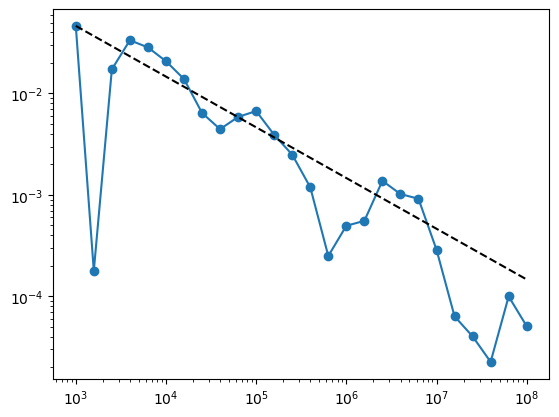

In [14]:
fig, ax = plt.subplots()
ax.loglog(M_checkpoints, error, 'o-')
ax.loglog(M_checkpoints, error[0]*(M_checkpoints[0]/M_checkpoints)**0.5, 'k--')
fig.savefig("plot.png")